
# Exercício — Regressão Linear e Múltipla com o *Iris* (sklearn)

**Objetivo:** aplicar regressão linear **simples** e **múltipla** no conjunto de dados *Iris* (da biblioteca `scikit-learn`) e avaliar as métricas: **MAE, MSE, RMSE e R²**.

## Dados
Usaremos o dataset `load_iris()` que contém 150 amostras de flores *Iris* com as seguintes variáveis contínuas (em cm):
- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

## Tarefas
1. Carregue o dataset `Iris` via `sklearn.datasets.load_iris`. Construa um `DataFrame` com nomes de colunas apropriados.
2. **Defina a variável alvo** `y` como **`petal length (cm)`**.
3. Crie dois conjuntos de recursos (features):
   - **Regressão Linear Simples:** `X1 = sepal length (cm)` (apenas essa coluna).
   - **Regressão Múltipla:** `Xn = sepal length (cm)`, `sepal width (cm)`, `petal width (cm)`.
4. Divida cada experimento (simples e múltipla) em **treino** e **teste** (25% para teste, `random_state=42`).
5. Treine modelos `LinearRegression` para cada experimento e **calcule as métricas** em teste: **MAE, MSE, RMSE e R²**.
6. Gere os seguintes **gráficos** em teste:
   - **Previsto vs Real** (inclua a linha de referência `y = x`).
   - **Resíduos vs Previsto** (inclua linha horizontal em `0`).
   - **(Somente para a regressão múltipla)**: gráfico de **barras dos coeficientes** de cada variável.
7. **Compare** as métricas entre a regressão simples e a múltipla. Explique, em 3–5 linhas, qual modelo desempenhou melhor e por quê.
8. (**Opcional**) Padronize as features com `StandardScaler` e observe se as métricas e os coeficientes mudam. Explique.

> **Regras dos gráficos:** usar apenas `matplotlib` (sem `seaborn`), **um gráfico por figura**, e **não definir cores específicas**.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class LinearRegressionModel:
    def __init__(self, scale=False):
        self.scale = scale
        self.scaler = None
        self.model = LinearRegression()
        self.fitted = False

    def fit(self, X, y, test_size=0.25, random_state=42):
        # Divisão treino/teste
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Padronização se necessário
        if self.scale:
            self.scaler = StandardScaler()
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)

        # Treinamento
        self.model.fit(self.X_train, self.y_train)

        # Previsões
        self.y_pred_train = self.model.predict(self.X_train)
        self.y_pred_test = self.model.predict(self.X_test)

        # Métricas
        self.metrics_train = self._compute_metrics(self.y_train, self.y_pred_train)
        self.metrics_test = self._compute_metrics(self.y_test, self.y_pred_test)

        self.fitted = True
        return self

    def show_metrics(self, title="Regressão Linear"):
        if not self.fitted:
            raise ValueError("O modelo ainda não foi treinado. Use .fit() antes.")
        self._print_metrics(self.metrics_train, title=f"Métricas - Treino ({title})")
        self._print_metrics(self.metrics_test, title=f"Métricas - Teste ({title})")
        print(f"\nCoeficiente(s): {self.model.coef_}")
        print(f"Intercepto: {self.model.intercept_}")

    def show_graphs(self):
        if not self.fitted:
            raise ValueError("O modelo ainda não foi treinado. Use .fit() antes.")

        # Gráfico: Previsto vs Real (Teste) + linha y = x
        plt.figure(figsize=(7,5))
        plt.scatter(self.y_test, self.y_pred_test, alpha=0.8)
        min_v = min(np.min(self.y_test), np.min(self.y_pred_test))
        max_v = max(np.max(self.y_test), np.max(self.y_pred_test))
        plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
        plt.title("Linear Simples — Previsto vs Real (Teste)")
        plt.xlabel("Real (y)")
        plt.ylabel("Previsto (ŷ)")
        plt.show()
        
        # Gráfico: Resíduos vs Previsto (Teste)
        resid_test = self.y_test - self.y_pred_test
        plt.figure(figsize=(7,5))
        plt.scatter(self.y_pred_test, resid_test, alpha=0.8)
        plt.axhline(0, linestyle="--")
        plt.title("Linear Simples — Resíduos vs Previsto (Teste)")
        plt.xlabel("Previsto (ŷ)")
        plt.ylabel("Resíduo (y - ŷ)")
        plt.show()   
    
    def _compute_metrics(self, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}     
    
    def _print_metrics(self, metrics, title=None):
        if title:
            print(f"\n=== {title} ===")
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")
    


In [ ]:
#! 1) Carregamento do dataset e preparação do DataFrame
iris_dataset = load_iris()

print(iris_dataset.keys())

# iris_dataset['data'] → contém os valores medidos de cada feature (números).
# É uma matriz onde cada linha é uma amostra (uma flor) e cada coluna é uma feature (medida).

# iris_dataset['feature_names'] → contém os nomes das features (nomes das colunas), não os valores.

base_df = pd.DataFrame(iris_dataset['data'], columns=iris_dataset['feature_names'])
base_df

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
#! 2) Definição de y e dos conjuntos X1 (simples) e Xn (múltipla)

y = base_df['petal length (cm)']

# __________________________ Regressao Linear Simples ___________________________
X_simple = base_df['sepal length (cm)'].to_numpy().reshape(-1, 1)
print(X_simple.shape)

# __________________________ Regressao Linear Multipla __________________________
X_multi = base_df.drop(columns=['petal length (cm)'])
print(X_multi.shape)


(150, 1)
(150, 3)


In [4]:
#! 3) Split treino/teste para cada experimento
# Realizei o split treino/teste de cada experimento dentro do metodo 'fit' da classe 'LinearRegressionModel'.

In [9]:
#! 4) Treinamento da regressão linear simples e cálculo das métricas

# __________________________ Regressao Linear Simples ___________________________
lrm_simple = LinearRegressionModel()
lrm_simple.fit(X=X_simple, y=y)
lrm_simple.show_metrics(title='Linear Simples')


=== Métricas - Treino (Linear Simples) ===
MAE: 0.7309
MSE: 0.7743
RMSE: 0.8800
R2: 0.7405

=== Métricas - Teste (Linear Simples) ===
MAE: 0.6436
MSE: 0.6751
RMSE: 0.8217
R2: 0.8011

Coeficiente(s): [1.82306088]
Intercepto: -6.821953149351428


In [ ]:
#! 5) Gráficos: Previsto vs Real e Resíduos vs Previsto (linear simples)
lrm_simple.show_graphs()

In [10]:
#! 6) Treinamento da regressão múltipla e cálculo das métricas

# __________________________ Regressao Linear Multipla __________________________
lrm_multi = LinearRegressionModel()
lrm_multi.fit(X=X_multi, y=y)
lrm_multi.show_metrics(title='Linear Multipla')


=== Métricas - Treino (Linear Multipla) ===
MAE: 0.2418
MSE: 0.0946
RMSE: 0.3075
R2: 0.9683

=== Métricas - Teste (Linear Multipla) ===
MAE: 0.2466
MSE: 0.1160
RMSE: 0.3406
R2: 0.9658

Coeficiente(s): [ 0.73564251 -0.64028226  1.46402752]
Intercepto: -0.3130909683040555


In [ ]:
#! 7) Gráficos: Previsto vs Real, Resíduos vs Previsto e Coeficientes (múltipla)
lrm_multi.show_graphs()

In [ ]:
# === Métricas - Teste  (Linear Simples) ===
# MAE: 0.6436
# MSE: 0.6751
# RMSE: 0.8217
# R2: 0.8011

# === Métricas - Teste  (Linear Multipla) ===
# MAE: 0.2466
# MSE: 0.1160
# RMSE: 0.3406
# R2: 0.9658


#! 8) Comparação e discussão das métricas (texto)

# A regressão linear simples, usando apenas 'sepal length (cm)' como preditora, obteve R² = 0.8011 e MSE = 0.6751. Já a regressão 
# múltipla, considerando todas as variáveis preditoras, alcançou R² = 0.9658 e MSE = 0.1160. Essa diferença mostra que a inclusão 
# de mais variáveis relevantes aumentou significativamente a capacidade do modelo de explicar a variabilidade da variável-alvo, 
# reduzindo também o erro médio.

In [12]:
# 9) (Opcional) Padronização e nova avaliação

# Com a padronização das variáveis preditoras, os valores de R² (~0,96) e MSE (~0,12) permaneceram inalterados. Isso acontece porque 
# a regressão linear do sklearn não é afetada pela escala das variáveis, desde que não haja regularização. Nesse caso, a padronização 
# não trouxe benefício em termos de performance. A única diferença observada foi nos valores dos coeficientes e do intercepto, que 
# mudaram devido à alteração da escala das variáveis.


lrm_multi_scale = LinearRegressionModel(scale=True)
lrm_multi_scale.fit(X=X_multi, y=y)
lrm_multi_scale.show_metrics(title='Linear Multipla')


=== Métricas - Treino (Linear Multipla) ===
MAE: 0.2418
MSE: 0.0946
RMSE: 0.3075
R2: 0.9683

=== Métricas - Teste (Linear Multipla) ===
MAE: 0.2466
MSE: 0.1160
RMSE: 0.3406
R2: 0.9658

Coeficiente(s): [ 0.59988536 -0.27862788  1.09012434]
Intercepto: 3.807142857142855


# Exercicio 2 - Repita a mesma análise para um novo dataset de sua escolha

In [32]:
from sklearn.datasets import fetch_california_housing

#! 1) Carregamento do dataset e preparação do DataFrame
california_housing_dataset = fetch_california_housing()

# MedInc     → renda média dos habitantes do bloco (em dezenas de milhares de dólares)
# HouseAge   → idade média das construções do bloco (em anos)
# AveRooms   → número médio de cômodos por residência
# AveBedrms  → número médio de quartos por residência
# Population → população total do bloco
# AveOccup   → número médio de pessoas por residência
# Latitude   → latitude geográfica do bloco
# Longitude  → longitude geográfica do bloco

# target → valor médio das casas (em centenas de milhares de dólares)


base_df = pd.DataFrame(california_housing_dataset['data'], columns=california_housing_dataset['feature_names'])
base_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [26]:
#! 2) Definição de y e dos conjuntos X1 (simples) e Xn (múltipla)

y = california_housing_dataset['target']

# __________________________ Regressao Linear Simples ___________________________
X_simple = base_df['MedInc'].to_numpy().reshape(-1, 1)
print(X_simple.shape)

# __________________________ Regressao Linear Multipla __________________________
X_multi = base_df
print(X_multi.shape)


(20640, 1)
(20640, 8)


In [27]:
# __________________________ Regressao Linear Simples ___________________________
lrm_simple = LinearRegressionModel()
lrm_simple.fit(X=X_simple, y=y)
lrm_simple.show_metrics(title='Linear Simples')


=== Métricas - Treino (Linear Simples) ===
MAE: 0.6257
MSE: 0.7014
RMSE: 0.8375
R2: 0.4743

=== Métricas - Teste (Linear Simples) ===
MAE: 0.6269
MSE: 0.7002
RMSE: 0.8368
R2: 0.4708

Coeficiente(s): [0.41788087]
Intercepto: 0.44967564199686105


In [28]:
# __________________________ Regressao Linear Multipla __________________________
lrm_multi = LinearRegressionModel()
lrm_multi.fit(X=X_multi, y=y)
lrm_multi.show_metrics(title='Linear Multipla')


=== Métricas - Treino (Linear Multipla) ===
MAE: 0.5295
MSE: 0.5206
RMSE: 0.7215
R2: 0.6099

=== Métricas - Teste (Linear Multipla) ===
MAE: 0.5297
MSE: 0.5411
RMSE: 0.7356
R2: 0.5911

Coeficiente(s): [ 4.47600069e-01  9.56752596e-03 -1.24755956e-01  7.94471254e-01
 -1.43902596e-06 -3.44307993e-03 -4.18555257e-01 -4.33405135e-01]
Intercepto: -37.027827585269286


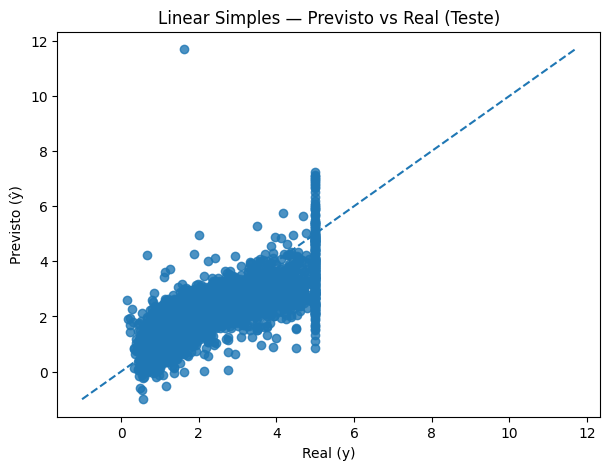

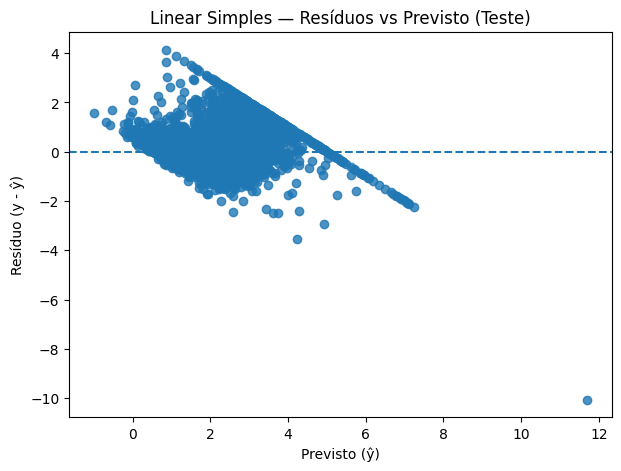

In [34]:
lrm_multi.show_graphs()